<a href="https://colab.research.google.com/github/sara-iqbal/Charity-Impact-and-Multi-Source-Reporting-Dashboard/blob/main/Charity_BI_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Charity Impact and Multi Source Reporting
Run every cell from top to bottom. All data here is **synthetic (made up)**. No real donors are used.
It builds messy data, cleans it with SQL views, checks quality, and creates the dashboard files.

In [1]:
import pandas as pd, numpy as np, sqlite3, json, os
import matplotlib.pyplot as plt
np.random.seed(42)
for d in ["data", "sql", "docs"]: os.makedirs(d, exist_ok=True)

# ---- Source 1: donor CRM export (with duplicate donor IDs on purpose)
regions = ["London","South East","North West","Midlands","Scotland","Wales"]
n = 1200
ids = [f"D{i:04d}" for i in range(1, n+1)]
donors = pd.DataFrame({"donor_id": ids,
    "region": np.random.choice(regions, n, p=[.30,.18,.15,.15,.12,.10]),
    "join_date": (pd.to_datetime("2022-01-01") + pd.to_timedelta(np.random.randint(0,1400,n), unit="D")).strftime("%Y-%m-%d")})
donors["email"] = donors.donor_id.str.lower() + "@example.org"
dupes = donors.sample(40, random_state=1).copy(); dupes["email"] = dupes.email.str.upper()
donors = pd.concat([donors, dupes], ignore_index=True)

# ---- Source 2: donations export (missing values, mixed currencies, orphans, duplicates)
N = 9000
active = np.random.rand(n, 3) < 0.45              # which donors give in which year
pairs = np.argwhere(active)
pick = pairs[np.random.randint(len(pairs), size=N)]
mw = np.array([1.0,.8,1.3,1.2,1.1,.8,.7,.7,.9,1.0,1.8,2.2]); mw = mw/mw.sum()
month = np.random.choice(12, N, p=mw) + 1
dt = pd.to_datetime(pd.DataFrame({"year": 2023 + pick[:,1], "month": month, "day": np.random.randint(1,28,N)}))
def campaign(m):
    if m in (11,12,1): return np.random.choice(["Winter Appeal","Emergency Appeal","Gift Aid Drive"], p=[.7,.15,.15])
    if m in (3,4,5):   return np.random.choice(["Spring Fundraiser","Marathon Challenge","Gift Aid Drive"], p=[.45,.4,.15])
    return np.random.choice(["Emergency Appeal","Gift Aid Drive","Summer Giving"], p=[.3,.3,.4])
donations = pd.DataFrame({"donation_id": [f"G{i:05d}" for i in range(N)],
    "donor_id": np.array(ids)[pick[:,0]], "gift_date": dt.dt.strftime("%Y-%m-%d"),
    "campaign": [campaign(m) for m in month],
    "currency": np.random.choice(["GBP","USD","EUR"], N, p=[.90,.06,.04]),
    "amount": np.round(np.random.lognormal(3.3, .8, N), 2)})
donations.loc[np.random.rand(N) < .01, "amount"] = np.nan
donations.loc[np.random.rand(N) < .02, "campaign"] = None
donations.loc[np.random.rand(N) < .01, "donor_id"] = "D9999"
donations = pd.concat([donations, donations.sample(15, random_state=2)], ignore_index=True)

# ---- Source 3a: event attendance   Source 3b: grants and finance sheet
camps = ["Winter Appeal","Spring Fundraiser","Marathon Challenge","Gift Aid Drive","Emergency Appeal","Summer Giving"]
events = pd.DataFrame({"event_id": range(1,61), "campaign": np.random.choice(camps, 60),
    "region": np.random.choice(regions, 60), "registered": np.random.randint(40,300,60)})
events["attended"] = (events.registered * np.random.uniform(.55,.95,60)).astype(int)
events["cost_gbp"] = np.random.randint(800, 9000, 60)
grants = pd.DataFrame({"grant_id": range(1,26),
    "funder": np.random.choice(["Trust A","Trust B","Lottery Fund","City Council","Health Fund","EU Fund"], 25),
    "programme": np.random.choice(["Youth Support","Food Aid","Mental Health","Community Hubs"], 25),
    "currency": np.random.choice(["GBP","EUR","USD"], 25, p=[.8,.12,.08]),
    "awarded": np.random.randint(20,200,25)*1000})
grants["spent"] = (grants.awarded * np.random.uniform(.6,1.0,25)).round(0)
grants.loc[[3,11,19], "spent"] = np.nan
for name, df in [("donors",donors),("donations",donations),("events",events),("grants",grants)]:
    df.to_csv(f"data/raw_{name}.csv", index=False)
print(len(donors), len(donations), len(events), len(grants))

1240 9015 60 25


## Step 2: SQL views that clean and join the data

In [2]:
SQL = """
CREATE TABLE fx (currency TEXT, rate_to_gbp REAL);
INSERT INTO fx VALUES ('GBP',1.0),('USD',0.79),('EUR',0.85);

-- Keep one row per donor ID
CREATE VIEW v_donors_clean AS
SELECT donor_id, region, join_date, LOWER(email) AS email FROM (
  SELECT *, ROW_NUMBER() OVER (PARTITION BY donor_id ORDER BY rowid) AS rn FROM donors)
WHERE rn = 1;

-- Remove duplicate gifts, missing amounts, unknown donors. Convert all money to GBP.
CREATE VIEW v_donations_clean AS
SELECT d.donation_id, d.donor_id, d.gift_date,
       CAST(strftime('%Y', d.gift_date) AS INTEGER) AS yr,
       strftime('%Y-%m', d.gift_date) AS ym,
       COALESCE(d.campaign, 'Unknown') AS campaign,
       dn.region, ROUND(d.amount * f.rate_to_gbp, 2) AS amount_gbp
FROM (SELECT *, ROW_NUMBER() OVER (PARTITION BY donation_id ORDER BY rowid) AS rn FROM donations) d
JOIN v_donors_clean dn ON dn.donor_id = d.donor_id
JOIN fx f ON f.currency = d.currency
WHERE d.rn = 1 AND d.amount IS NOT NULL AND d.amount > 0;

CREATE VIEW v_campaign AS
SELECT campaign, COUNT(*) AS gifts, COUNT(DISTINCT donor_id) AS donors,
       ROUND(SUM(amount_gbp),0) AS raised, ROUND(AVG(amount_gbp),2) AS avg_gift
FROM v_donations_clean GROUP BY campaign;

CREATE VIEW v_event_summary AS
SELECT campaign, COUNT(*) AS events, SUM(attended) AS attended,
       ROUND(100.0*SUM(attended)/SUM(registered),1) AS attend_pct, SUM(cost_gbp) AS event_cost
FROM events GROUP BY campaign;

CREATE VIEW v_retention AS
SELECT a.yr AS from_year, a.yr + 1 AS to_year, COUNT(DISTINCT a.donor_id) AS donors_start,
       COUNT(DISTINCT b.donor_id) AS donors_kept,
       ROUND(100.0*COUNT(DISTINCT b.donor_id)/COUNT(DISTINCT a.donor_id),1) AS retention_pct
FROM v_donations_clean a LEFT JOIN v_donations_clean b ON b.donor_id = a.donor_id AND b.yr = a.yr + 1
WHERE a.yr < 2025 GROUP BY a.yr;

CREATE VIEW v_grants AS
SELECT g.grant_id, funder, programme, ROUND(awarded*f.rate_to_gbp,0) AS awarded_gbp,
       ROUND(spent*f.rate_to_gbp,0) AS spent_gbp,
       ROUND(100.0*spent/awarded,1) AS pct_spent
FROM grants g JOIN fx f ON f.currency = g.currency;
"""
open("sql/views.sql","w").write(SQL)
con = sqlite3.connect(":memory:")
for name, df in [("donors",donors),("donations",donations),("events",events),("grants",grants)]:
    df.to_sql(name, con, index=False)
con.executescript(SQL)
q = lambda s: pd.read_sql(s, con)
print(q("SELECT * FROM v_campaign"))

             campaign  gifts  donors   raised  avg_gift
0    Emergency Appeal   1468     737  54052.0     36.82
1      Gift Aid Drive   1697     772  63305.0     37.30
2  Marathon Challenge    968     598  33848.0     34.97
3   Spring Fundraiser   1086     629  39012.0     35.92
4       Summer Giving   1224     675  43641.0     35.65
5             Unknown    149     134   6136.0     41.18
6       Winter Appeal   2232     829  83544.0     37.43


## Step 3: Data quality rules and a validation report

In [3]:
rules = [
 ("Duplicate donor IDs", "SELECT COUNT(*) - COUNT(DISTINCT donor_id) FROM donors", "Kept the first row per donor ID"),
 ("Duplicate donation IDs", "SELECT COUNT(*) - COUNT(DISTINCT donation_id) FROM donations", "Kept the first row per donation ID"),
 ("Missing gift amount", "SELECT COUNT(*) FROM donations WHERE amount IS NULL", "Removed from totals"),
 ("Missing campaign name", "SELECT COUNT(*) FROM donations WHERE campaign IS NULL", "Labelled as Unknown"),
 ("Gifts not in GBP", "SELECT COUNT(*) FROM donations WHERE currency <> 'GBP'", "Converted to GBP with the fx table"),
 ("Gifts from unknown donor ID", "SELECT COUNT(*) FROM donations WHERE donor_id NOT IN (SELECT donor_id FROM donors)", "Removed from totals"),
 ("Grants with missing spend", "SELECT COUNT(*) FROM grants WHERE spent IS NULL", "Left blank and flagged"),
]
report = pd.DataFrame([(r, int(q(s).iloc[0,0]), a) for r, s, a in rules], columns=["rule","rows_affected","action"])
raw_rows = len(donations); clean_rows = int(q("SELECT COUNT(*) FROM v_donations_clean").iloc[0,0])
report.loc[len(report)] = ["Reconciliation: raw gifts vs clean gifts", raw_rows - clean_rows, f"{raw_rows} raw rows became {clean_rows} clean rows"]
report.to_csv("data/validation_report.csv", index=False)
report

,rule,rows_affected,action
0,Duplicate donor IDs,40,Kept the first row per donor ID
1,Duplicate donation IDs,15,Kept the first row per donation ID
2,Missing gift amount,84,Removed from totals
3,Missing campaign name,152,Labelled as Unknown
4,Gifts not in GBP,922,Converted to GBP with the fx table
5,Gifts from unknown donor ID,93,Removed from totals
6,Grants with missing spend,3,Left blank and flagged
7,Reconciliation: raw gifts vs clean gifts,191,9015 raw rows became 8824 clean rows


## Step 4: Results and charts

Total raised £323,539 from 8,824 gifts, average gift £36.67


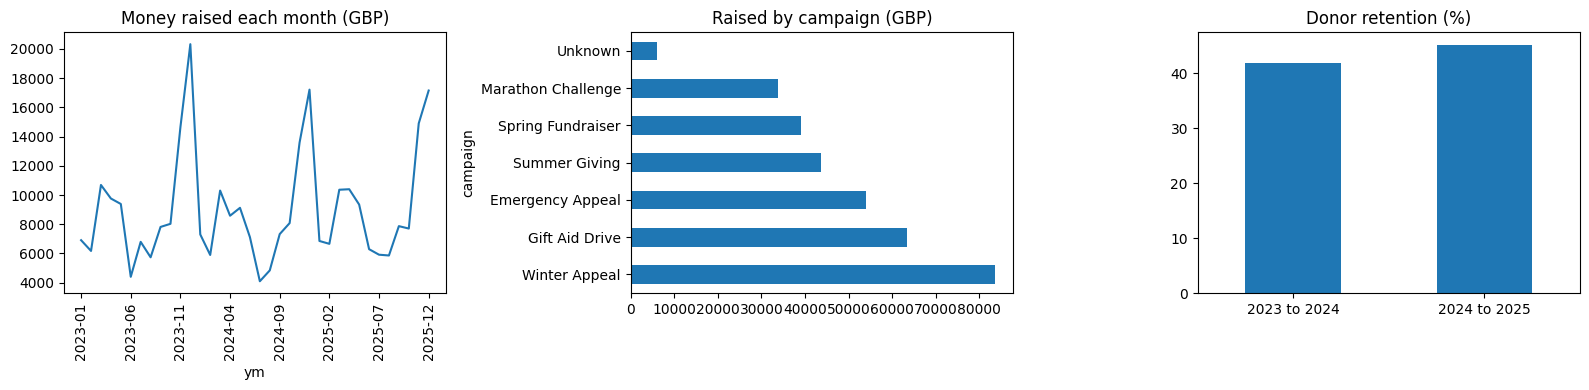

In [4]:
clean = q("SELECT * FROM v_donations_clean")
total, gifts, avg = clean.amount_gbp.sum(), len(clean), clean.amount_gbp.mean()
by_year = clean.groupby("yr").amount_gbp.sum().round(0)
camp = q("SELECT * FROM v_campaign").merge(q("SELECT * FROM v_event_summary"), on="campaign", how="left").sort_values("raised", ascending=False)
ret = q("SELECT * FROM v_retention")
monthly = clean.groupby("ym").amount_gbp.sum()
print(f"Total raised £{total:,.0f} from {gifts:,} gifts, average gift £{avg:.2f}")
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
monthly.plot(ax=ax[0], title="Money raised each month (GBP)"); ax[0].tick_params(axis="x", labelrotation=90)
camp.set_index("campaign").raised.plot.barh(ax=ax[1], title="Raised by campaign (GBP)")
ret.set_index(ret.from_year.astype(str) + " to " + ret.to_year.astype(str)).retention_pct.plot.bar(ax=ax[2], title="Donor retention (%)", rot=0)
plt.tight_layout(); plt.savefig("docs/charts.png", dpi=120); plt.show()

## Step 5: Export clean files for Power BI and build the web dashboard

In [5]:
clean.to_csv("data/clean_donations.csv", index=False)
q("SELECT * FROM v_donors_clean").to_csv("data/clean_donors.csv", index=False)
camp.to_csv("data/campaign_summary.csv", index=False)
ret.to_csv("data/retention.csv", index=False)
q("SELECT * FROM v_grants").to_csv("data/grants_clean.csv", index=False)

flat = q("SELECT ym, campaign, region, ROUND(SUM(amount_gbp),0) AS amt, COUNT(*) AS gifts FROM v_donations_clean GROUP BY ym, campaign, region")
DATA = flat.to_json(orient="records"); RET = ret.to_json(orient="records")
GR = q("SELECT * FROM v_grants").fillna(-1).to_json(orient="records")
HTML = open("docs/template.html").read() if os.path.exists("docs/template.html") else None
print(len(flat), "dashboard rows ready")

745 dashboard rows ready


## Step 6: The dashboard page
The cell below writes `docs/index.html`. Upload the `docs` folder to GitHub and turn on GitHub Pages to publish it.

In [6]:
HTML_TEMPLATE = '<!doctype html><html lang="en"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1"><title>Charity Impact Dashboard</title>\n<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.min.js"></script>\n<style>:root{--bg:#f6f7fb;--card:#fff;--tx:#1d2433;--mu:#65708a;--ac:#5b3fd0}\n@media(prefers-color-scheme:dark){:root{--bg:#12141c;--card:#1c2030;--tx:#e8ebf5;--mu:#98a2bd;--ac:#9c86ff}}\nbody{margin:0;font-family:system-ui,Arial,sans-serif;background:var(--bg);color:var(--tx);padding:20px}\nh1{margin:0 0 4px}p.s{color:var(--mu);margin:0 0 16px}.bar{display:flex;gap:12px;flex-wrap:wrap;align-items:center;margin-bottom:16px}\nselect,button{padding:8px 10px;border-radius:8px;border:1px solid var(--mu);background:var(--card);color:var(--tx)}\n.k{display:grid;grid-template-columns:repeat(auto-fit,minmax(150px,1fr));gap:12px;margin-bottom:16px}\n.c{background:var(--card);border-radius:12px;padding:14px}.c b{display:block;font-size:26px;color:var(--ac)}.c span{color:var(--mu);font-size:13px}\n.g{display:grid;grid-template-columns:repeat(auto-fit,minmax(320px,1fr));gap:12px}.h{height:260px;position:relative}\ntable{width:100%;border-collapse:collapse;font-size:14px}td,th{padding:6px;text-align:left;border-bottom:1px solid var(--mu)}\n.w{overflow-x:auto}</style></head><body>\n<h1>Charity Impact Dashboard</h1><p class="s">Synthetic demo data. Click a bar to drill down. Click it again to undo.</p>\n<div class="bar"><label>Year <select id="yr"><option value="all">All years</option><option>2023</option><option>2024</option><option>2025</option></select></label>\n<label>Region <select id="rg"><option value="all">All regions</option></select></label><button id="clr">Clear filters</button><span id="act" class="s"></span></div>\n<div class="k"><div class="c"><b id="k1"></b><span>Money raised</span></div><div class="c"><b id="k2"></b><span>Number of gifts</span></div><div class="c"><b id="k3"></b><span>Average gift</span></div></div>\n<div class="g"><div class="c"><h3>Donations by month</h3><div class="h"><canvas id="c1"></canvas></div></div>\n<div class="c"><h3>Campaign performance</h3><div class="h"><canvas id="c2"></canvas></div></div>\n<div class="c"><h3>Raised by region</h3><div class="h"><canvas id="c3"></canvas></div></div>\n<div class="c"><h3>Donor retention (%)</h3><div class="h"><canvas id="c4"></canvas></div></div></div>\n<div class="c w" style="margin-top:12px"><h3>Grants: awarded and spent</h3><table id="gt"></table></div>\n<script>\nconst D=__DATA__,RET=__RET__,GR=__GR__;const f={yr:\'all\',rg:\'all\',cp:\'all\'};\nconst fm=n=>\'£\'+Math.round(n).toLocaleString(\'en-GB\');\nconst rows=s=>D.filter(r=>(s==\'yr\'||f.yr==\'all\'||r.ym.slice(0,4)==f.yr)&&(s==\'rg\'||f.rg==\'all\'||r.region==f.rg)&&(s==\'cp\'||f.cp==\'all\'||r.campaign==f.cp));\nconst grp=(rs,k)=>{const m={};rs.forEach(r=>m[r[k]]=(m[r[k]]||0)+r.amt);return m};\nconst REG=[...new Set(D.map(r=>r.region))].sort();REG.forEach(x=>rg.add(new Option(x,x)));\nconst mk=(id,type,click)=>new Chart(document.getElementById(id),{type,data:{labels:[],datasets:[{data:[],backgroundColor:\'#7c5cff\',borderColor:\'#7c5cff\',tension:.3}]},options:{indexAxis:type==\'bar\'&&id==\'c2\'?\'y\':\'x\',maintainAspectRatio:false,plugins:{legend:{display:false}},onClick:click?(e,a,ch)=>{if(a.length){const l=ch.data.labels[a[0].index];click(l)}}:undefined}});\nconst c1=mk(\'c1\',\'line\'),c2=mk(\'c2\',\'bar\',l=>{f.cp=f.cp==l?\'all\':l;draw()}),c3=mk(\'c3\',\'bar\',l=>{f.rg=f.rg==l?\'all\':l;rg.value=f.rg;draw()}),c4=mk(\'c4\',\'bar\');\nconst set=(c,o)=>{c.data.labels=Object.keys(o);c.data.datasets[0].data=Object.values(o);c.update()};\nfunction draw(){const all=rows(\'\');k1.textContent=fm(all.reduce((a,r)=>a+r.amt,0));const g=all.reduce((a,r)=>a+r.gifts,0);k2.textContent=g.toLocaleString();k3.textContent=g?fm(all.reduce((a,r)=>a+r.amt,0)/g):\'\';\nconst m=grp(all,\'ym\');set(c1,Object.fromEntries(Object.entries(m).sort()));\nconst cp=Object.entries(grp(rows(\'cp\'),\'campaign\')).sort((a,b)=>b[1]-a[1]);set(c2,Object.fromEntries(cp));\nset(c3,grp(rows(\'rg\'),\'region\'));\nset(c4,Object.fromEntries(RET.map(r=>[r.from_year+\' to \'+r.to_year,r.retention_pct])));\nact.textContent=\'Showing: \'+[f.yr,f.rg,f.cp].map(x=>x==\'all\'?\'all\':x).join(\' / \')}\nyr.onchange=()=>{f.yr=yr.value;draw()};rg.onchange=()=>{f.rg=rg.value;draw()};clr.onclick=()=>{f.yr=f.rg=f.cp=\'all\';yr.value=rg.value=\'all\';draw()};\ngt.innerHTML=\'<tr><th>Funder</th><th>Programme</th><th>Awarded</th><th>Spent</th><th>% spent</th></tr>\'+GR.map(r=>`<tr><td>${r.funder}</td><td>${r.programme}</td><td>${fm(r.awarded_gbp)}</td><td>${r.spent_gbp<0?\'Missing\':fm(r.spent_gbp)}</td><td>${r.pct_spent<0?\'n/a\':r.pct_spent+\'%\'}</td></tr>`).join(\'\');\ndraw();\n</script></body></html>'
page = HTML_TEMPLATE.replace("__DATA__", DATA).replace("__RET__", RET).replace("__GR__", GR)
open("docs/index.html", "w").write(page)
print("Dashboard written to docs/index.html")
try:
    import shutil; from google.colab import files
    shutil.make_archive("charity_bi_output", "zip", "."); files.download("charity_bi_output.zip")
except ImportError:
    pass

Dashboard written to docs/index.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>